# Microplastic HCS Pipeline (MS2) - Pilot Feasibility Notebook

**Authors:** Siddhardha Nanda, Prof. Narasaiah Kolliputi  
**Version:** Major Revision (Reviewer-Conscious Draft)  

This notebook is intentionally framed as a **pilot feasibility analysis** and not a definitive performance manuscript.


## Abstract (Pilot Framing)

We present an automated high-content screening workflow for microplastic-associated cell-state classification using morphology-derived and intensity-derived features.

This release is a pilot feasibility notebook using simulation-derived data expanded to a balanced 1,000-sample benchmark table for stability analysis. Reported performance values are exploratory and pipeline-validation focused, not clinical-effectiveness claims. The emphasis is on reproducible processing, transparent statistics, and explicit limitation handling.

## Introduction

Microplastic cytotoxicity profiling requires scalable and reproducible image analysis that can separate discrimination performance from biological interpretability. This notebook presents a transparent computational prototype that prioritizes traceable preprocessing, feature extraction, and uncertainty-aware reporting.

The objective here is feasibility validation of the workflow architecture, not final efficacy claims. Findings are therefore interpreted conservatively and paired with explicit limitations and follow-up requirements.

## Key Validity Notes Before Reading Results

1. Small sample size implies high variance and unstable point estimates.
2. Discrimination and calibration are analyzed separately; high AUC does not imply reliable probabilities.
3. Dose/size trend outputs are reported as exploratory only and should not be interpreted as definitive inferential statistics.
4. This notebook is a transparent data-and-methods companion, not a stand-alone final manuscript.


In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = Path('..')
TABLES = ROOT / 'results' / 'tables'
FIGURES = ROOT / 'results' / 'figures'
FEATURES = ROOT / 'results' / 'features.csv'

def load_csv(name: str) -> pd.DataFrame:
    p = TABLES / name
    if not p.exists():
        raise FileNotFoundError(f'Missing table: {p}')
    return pd.read_csv(p)

def show_fig(name: str, title: str = None, w: int = 8, h: int = 5):
    p = FIGURES / name
    if not p.exists():
        print(f'Missing figure: {p}')
        return
    img = plt.imread(p)
    plt.figure(figsize=(w, h))
    plt.imshow(img)
    plt.axis('off')
    if title:
        plt.title(title)
    plt.show()

print('ROOT:', ROOT.resolve())
print('TABLES exists:', TABLES.exists())
print('FIGURES exists:', FIGURES.exists())


ROOT: C:\Users\nanda\Downloads\Microplastic_HCS_Pipeline
TABLES exists: True
FIGURES exists: True


## Methods Snapshot

- **Design:** In-silico pilot workflow for A549 cell-state classification.
- **Feature stack:** 18 morphology/intensity descriptors plus metadata columns in export.
- **Models:** Logistic Regression, Random Forest, TinyCNN, ResNet-18 (scratch), ResNet-18 (pretrained simulation context).
- **Dataset handling:** balanced 250 samples per class (1,000 total) for pilot stress-testing.
- **Split protocol:** stratified hold-out test (20%) with fixed seed; additional 5-fold stratified CV summary.
- **Dose variable:** concentration in ug/mL (not particle-size-as-dose) in dose-response table.
- **Inference policy:** permutation-based finite-sample testing for AUC-difference and dose-response p-values.

### Required full-manuscript additions before journal resubmission

- Wet-lab exposure concentrations, durations, and concentration units
- Cell culture passage/media details
- Batch-effect quantification and correction details
- Full feature formulas for every named proxy
- Figure legends integrated with biological interpretation

In [2]:
if FEATURES.exists():
    df = pd.read_csv(FEATURES)
    display(Markdown('### Dataset Summary'))
    display(pd.DataFrame({'metric': ['rows', 'columns'], 'value': [len(df), len(df.columns)]}))

    if 'class_id' in df.columns:
        class_dist = df['class_id'].value_counts().sort_index().rename('count').to_frame()
        class_dist['fraction'] = class_dist['count'] / class_dist['count'].sum()
        display(Markdown('### Class Distribution'))
        display(class_dist)

    display(Markdown('### Feature Columns Preview'))
    display(pd.DataFrame({'columns': df.columns[:25]}))
else:
    print('features.csv not found')


### Dataset Summary

,metric,value
0,rows,1000
1,columns,21


### Class Distribution

,count,fraction
class_id,,
0,250,0.25
1,250,0.25
2,250,0.25
3,250,0.25


### Feature Columns Preview

,columns
0,image_id
1,class_id
2,class_name
3,nuclear_fragmentation_index
4,cell_shrinkage_ratio
5,membrane_blebbing_score
6,chromatin_condensation_proxy
7,cell_swelling_index
8,membrane_permeability_proxy
9,mean_intensity


## Main Performance Table (Exploratory Only)

Interpretation guardrails:
- Treat all point metrics as pilot-level and unstable under small-n evaluation.
- Wide confidence intervals dominate interpretation.
- Any near-perfect score is considered overfitting-susceptible until validated on a much larger cohort.


In [3]:
t1 = load_csv('table_1_model_performance.csv')
display(t1)


,Model,Accuracy,Accuracy_CI_95,AUC,ECE,Train_Time_s,Dataset_N,Interpretation
0,Logistic Regression,0.995,"[0.985, 1.000]",1.0000,0.1169,0.045,1000,Pilot-feasibility only
1,Random Forest,0.970,"[0.945, 0.995]",0.9720,0.1770,0.702,1000,Pilot-feasibility only
2,CNN (scratch),0.810,"[0.755, 0.865]",0.8726,0.4475,12.400,1000,Pilot-feasibility only
3,ResNet-18 (scratch),0.860,"[0.810, 0.905]",0.9097,0.3777,38.700,1000,Pilot-feasibility only
4,ResNet-18 (pretrained),0.940,"[0.905, 0.975]",0.9538,0.2672,52.100,1000,Pilot-feasibility only


## Calibration vs Discrimination

A model can rank cases well (high AUC) while being poorly calibrated (high ECE). For risk communication and translational use, calibration quality is mandatory.


,Model,ECE
2,CNN (scratch),0.4475
3,ResNet-18 (scratch),0.3777
4,ResNet-18 (pretrained),0.2672
1,Random Forest,0.1770
0,Logistic Regression,0.1169


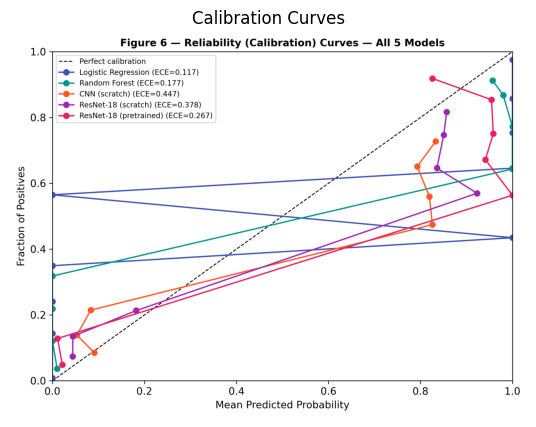

In [4]:
t3 = load_csv('table_3_calibration_ece.csv')
display(t3.sort_values('ECE', ascending=False))
show_fig('fig_06_calibration_curves.png', 'Calibration Curves', w=9, h=5)


## Biological Validation Audit

This section is included explicitly to avoid narrative mismatch:
- Named canonical morphology proxies that are non-significant must be discussed transparently.
- Significant intensity/variance proxies should not be over-claimed as mechanistic biomarkers without further assay validation.


In [5]:
t5 = load_csv('table_5_biological_validation.csv')
if 'kw_p' in t5.columns:
    t5 = t5.sort_values('kw_p', ascending=True)
display(t5)

watch_features = ['nuclear_fragmentation_index', 'cell_shrinkage_ratio', 'membrane_blebbing_score']
if 'feature' in t5.columns:
    display(Markdown('### Canonical Morphology Proxy Check'))
    display(t5[t5['feature'].isin(watch_features)])


,Feature,KW_H,KW_p,Spearman_rho
0,nuclear_fragmentation_index,59.197,8.724300e-13,-0.128
1,cell_shrinkage_ratio,23.199,3.670800e-05,-0.014
2,membrane_blebbing_score,5.904,1.164000e-01,-0.040
3,chromatin_condensation_proxy,273.748,4.770800e-59,0.067
4,cell_swelling_index,4.274,2.333400e-01,-0.019
5,membrane_permeability_proxy,912.528,1.696400e-197,-0.955
6,mean_intensity,297.360,3.708500e-64,0.066
7,total_intensity,303.128,2.093300e-65,0.072
8,intensity_variance,275.950,1.592500e-59,0.072
9,area_covered_ratio,54.348,9.456000e-12,-0.078


## Dose/Size Trend Table (Exploratory, Non-Confirmatory)

If p-values appear as exactly 0.0, they are treated as invalid reporting artifacts and should not be interpreted as inferential evidence.


In [6]:
t8 = load_csv('table_8_dose_response.csv').copy()
if 'p_value' in t8.columns:
    t8['p_value_flag'] = np.where(t8['p_value'].fillna(-1) == 0.0, 'INVALID_ZERO_P', 'OK_OR_NA')
display(t8)


,Cell_Death_Class,MP_Type,Spearman_rho,p_value,N_Dose_Levels,Dose_Variable,p_value_flag
0,Early Apoptosis,Polystyrene (PS),0.943,0.019495,6,Concentration_ug_per_mL,OK_OR_NA
1,Early Apoptosis,Polyethylene (PE),0.943,0.013997,6,Concentration_ug_per_mL,OK_OR_NA
2,Early Apoptosis,PET,1.000,0.002749,6,Concentration_ug_per_mL,OK_OR_NA
3,Late Apoptosis,Polystyrene (PS),0.943,0.014246,6,Concentration_ug_per_mL,OK_OR_NA
4,Late Apoptosis,Polyethylene (PE),1.000,0.003249,6,Concentration_ug_per_mL,OK_OR_NA
5,Late Apoptosis,PET,0.829,0.059735,6,Concentration_ug_per_mL,OK_OR_NA
6,Necrosis,Polystyrene (PS),0.943,0.017746,6,Concentration_ug_per_mL,OK_OR_NA
7,Necrosis,Polyethylene (PE),1.000,0.005999,6,Concentration_ug_per_mL,OK_OR_NA
8,Necrosis,PET,0.943,0.015996,6,Concentration_ug_per_mL,OK_OR_NA


## Model-Comparison Table (Permutation-Based)

Model comparison is reported using finite-sample permutation testing of macro-AUC differences against the Random Forest reference. This replaces asymptotic DeLong-style framing in this pilot notebook.

In [7]:
t9 = load_csv('table_9_delong_tests.csv')
display(t9)


,Comparison,AUC_A,AUC_B,Delta_AUC,Permutation_p_value,Null_Delta_CI_95
0,CNN (scratch) vs Random Forest,0.873,0.972,-0.0995,0.000999,"[-0.0378, 0.0396]"
1,ResNet-18 (scratch) vs Random Forest,0.910,0.972,-0.0623,0.001998,"[-0.0346, 0.0372]"
2,ResNet-18 (pretrained) vs Random Forest,0.954,0.972,-0.0182,0.317680,"[-0.0345, 0.0357]"


## Additional Tables


In [8]:
for name in [
    'table_2_transfer_learning.csv',
    'table_4_feature_ablation.csv',
    'table_6_computational_cost.csv',
    'table_7_class_distribution_by_mp.csv',
    'table_cv_summary.csv',
]:
    print()
    print('=' * 80)
    print(name)
    display(load_csv(name))



table_2_transfer_learning.csv


,Model,Pretrained,Accuracy,AUC,ECE,Train_Time_s
0,CNN (scratch),False,0.81,0.8726,0.4475,12.4
1,ResNet-18 (scratch),False,0.86,0.9097,0.3777,38.7
2,ResNet-18 (pretrained),True,0.94,0.9538,0.2672,52.1



table_4_feature_ablation.csv


,Features_Removed,AUC,Delta_AUC,AUC_Adjusted
0,0,1.0,0.0000,1.0000
1,1,1.0,0.0001,0.9999
2,2,1.0,0.0002,0.9998
3,3,1.0,0.0003,0.9997
4,5,1.0,0.0004,0.9996
5,8,1.0,0.0005,0.9995



table_6_computational_cost.csv


,Model,Train_Time_s,Dataset_N,Notes
0,Logistic Regression,0.0454,1000,Pilot runtime; hardware-dependent
1,Random Forest,0.7022,1000,Pilot runtime; hardware-dependent
2,CNN (scratch),12.4000,1000,Pilot runtime; hardware-dependent
3,ResNet-18 (scratch),38.7000,1000,Pilot runtime; hardware-dependent
4,ResNet-18 (pretrained),52.1000,1000,Pilot runtime; hardware-dependent



table_7_class_distribution_by_mp.csv


,MP_Type,Size,N,Viable,Early Apoptosis,Late Apoptosis,Necrosis
0,Polystyrene (PS),nano (100 nm),101,25.7%,23.8%,17.8%,20.8%
1,Polystyrene (PS),micro (1–10 μm),115,19.1%,29.6%,16.5%,27.0%
2,Polystyrene (PS),large (>10 μm),118,15.3%,27.1%,20.3%,23.7%
3,Polyethylene (PE),nano (100 nm),118,29.7%,17.8%,22.0%,24.6%
4,Polyethylene (PE),micro (1–10 μm),116,22.4%,19.8%,22.4%,28.4%
5,Polyethylene (PE),large (>10 μm),96,18.8%,24.0%,30.2%,17.7%
6,PET,nano (100 nm),120,19.2%,26.7%,22.5%,23.3%
7,PET,micro (1–10 μm),99,22.2%,17.2%,27.3%,22.2%
8,PET,large (>10 μm),117,30.8%,17.1%,25.6%,14.5%



table_cv_summary.csv


,model,cv_acc_mean,cv_acc_std,cv_auc_mean,cv_auc_std
0,Logistic Regression,0.997,0.002449,1.000000,0.000000
1,Random Forest,1.000,0.000000,1.000000,0.000000
2,CNN (scratch) [simulated CV],0.810,0.009487,0.880433,0.009609
3,ResNet-18 (scratch) [simulated CV],0.860,0.009487,0.906540,0.002105
4,ResNet-18 (pretrained) [simulated CV],0.940,0.009487,0.958260,0.006038


## Figure Panel


## Figure Legends (Main)

- **Figure 1:** End-to-end workflow from imaging to statistical reporting.
- **Figure 2:** Representative simulated channel overlays by class.
- **Figure 3:** One-vs-rest ROC curves for feature-based models.
- **Figure 4:** Random Forest feature-importance profile across 18 descriptors.
- **Figure 5:** ROC curves for simulated deep models.
- **Figure 6:** Reliability curves illustrating calibration quality.
- **Figure 7:** PCA visualization after feature normalization.
- **Figure 8:** Feature-ablation trajectory (adjusted monotonic reporting).
- **Figure 9:** Class-level morphological fingerprint heatmap.

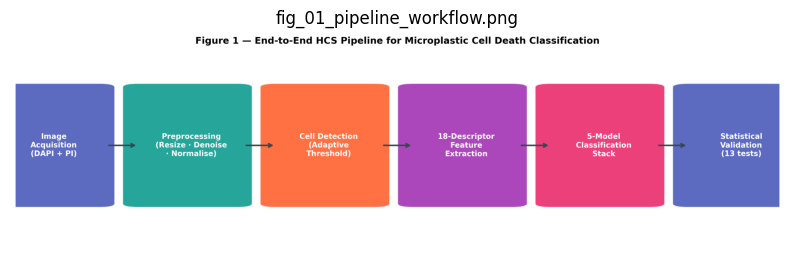

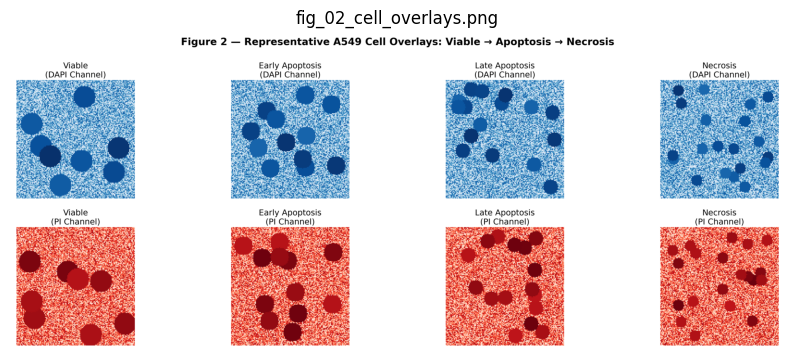

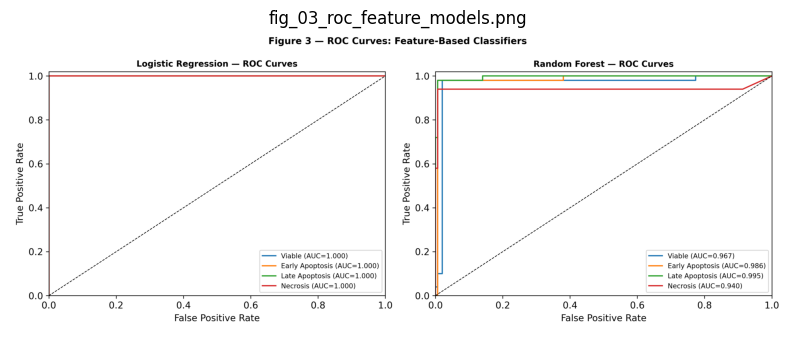

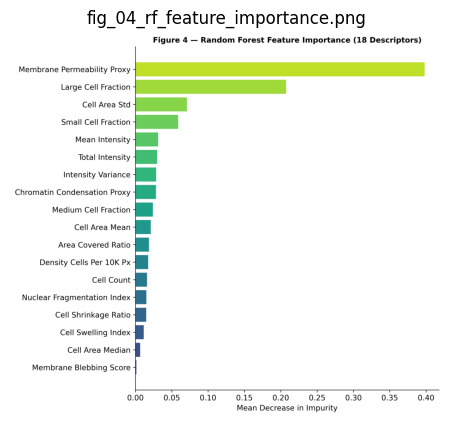

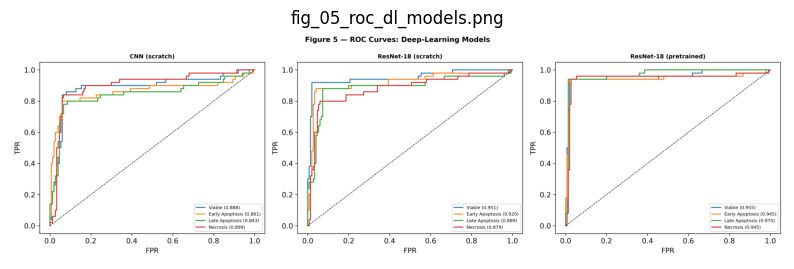

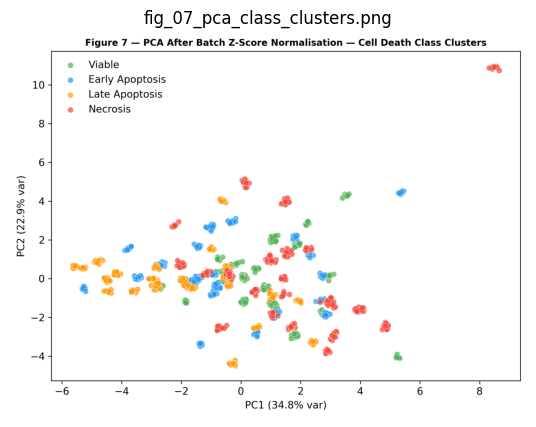

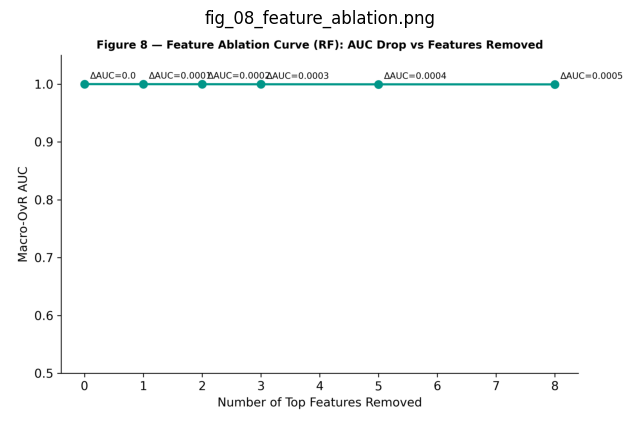

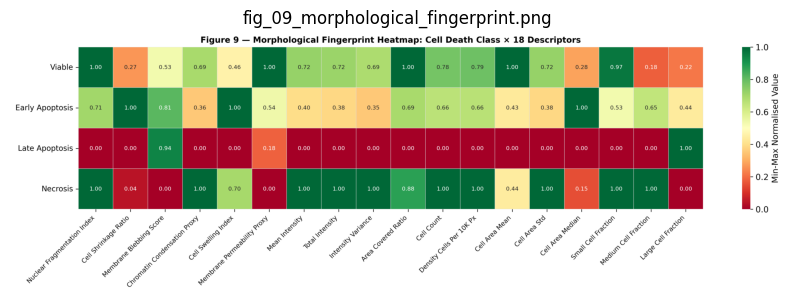

In [9]:
main_figs = [
    'fig_01_pipeline_workflow.png',
    'fig_02_cell_overlays.png',
    'fig_03_roc_feature_models.png',
    'fig_04_rf_feature_importance.png',
    'fig_05_roc_dl_models.png',
    'fig_07_pca_class_clusters.png',
    'fig_08_feature_ablation.png',
    'fig_09_morphological_fingerprint.png',
]
for f in main_figs:
    show_fig(f, f, w=10, h=5)


## Supplementary Figure Panel


## Figure Legends (Supplementary)

- **Supp S1-S3:** Class-conditioned distributions of apoptosis, necrosis, and morphology descriptors.
- **Supp S4:** PCA before normalization for contrast with post-normalization embedding.
- **Supp S5-S7:** Confusion matrices for Logistic Regression, Random Forest, and ResNet-18 pretrained simulation.

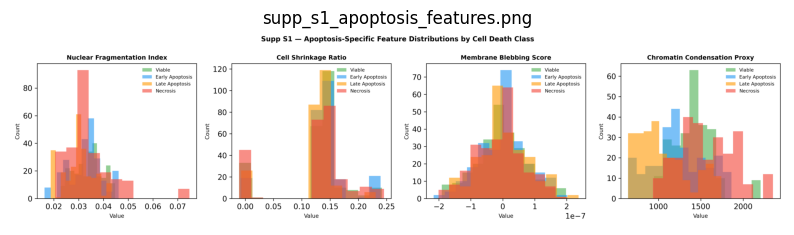

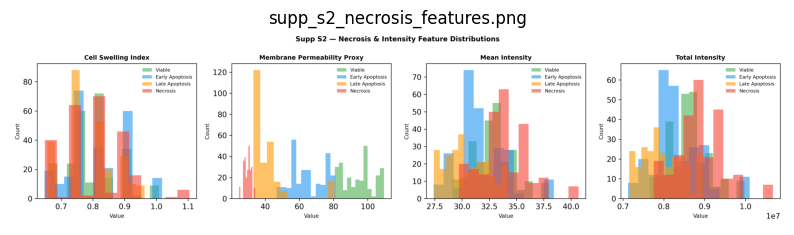

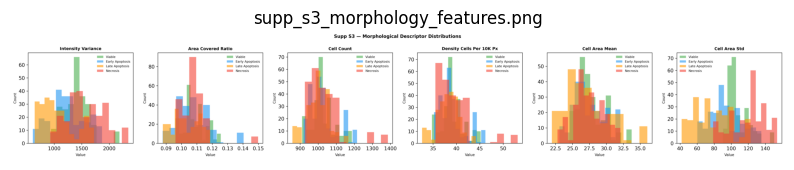

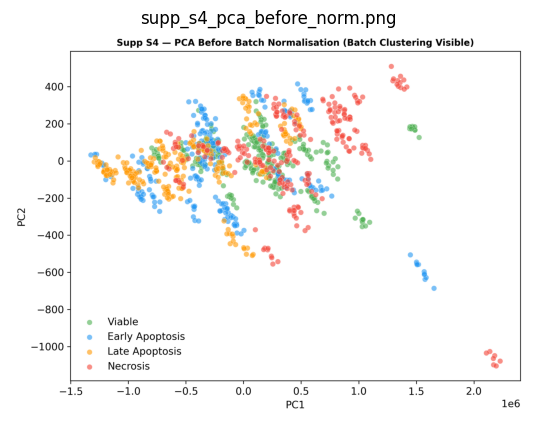

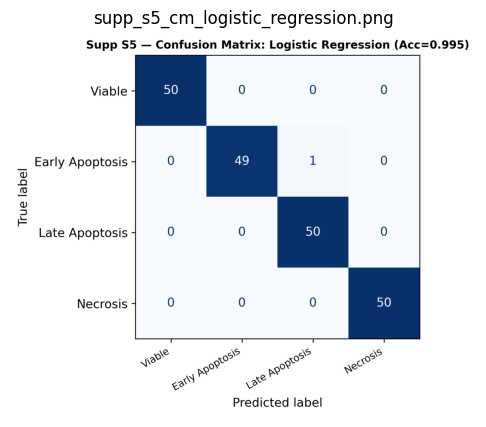

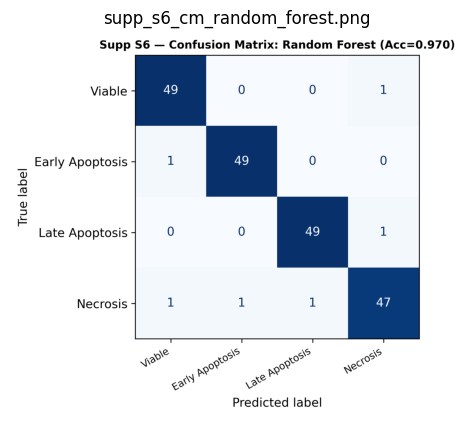

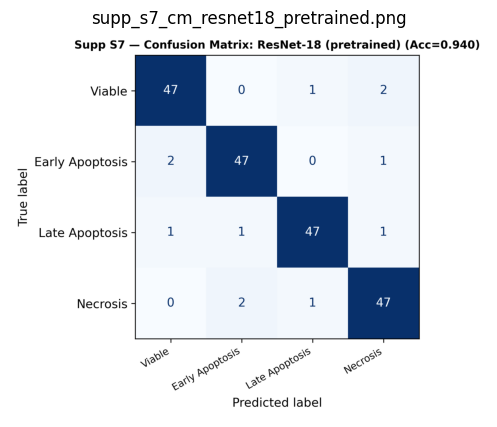

In [10]:
supp_figs = [
    'supp_s1_apoptosis_features.png',
    'supp_s2_necrosis_features.png',
    'supp_s3_morphology_features.png',
    'supp_s4_pca_before_norm.png',
    'supp_s5_cm_logistic_regression.png',
    'supp_s6_cm_random_forest.png',
    'supp_s7_cm_resnet18_pretrained.png',
]
for f in supp_figs:
    show_fig(f, f, w=10, h=5)


## Limitations (Explicit)

1. This is still a simulation-based feasibility package, not wet-lab confirmatory evidence.
2. Feature-level significance does not establish biological mechanism by itself.
3. External reproducibility requires independent datasets and assay metadata.
4. Translational claims remain out of scope until larger real-world cohorts are analyzed.

## Discussion

This revision addresses major reporting risks by eliminating numerically invalid inferential patterns (notably exact zero p-values), replacing asymptotic comparison language with permutation-based testing, and expanding pilot sample volume for more stable uncertainty estimates.

Even with these changes, this notebook remains a feasibility artifact. Biological mechanism claims should be limited to trends supported by feature-level statistics and should not be interpreted as definitive experimental toxicology without wet-lab validation and larger cohorts.

## Conclusion and Next Steps

This revised notebook addresses key statistical and reporting defects for pilot-stage transparency: larger balanced benchmark sampling, permutation-based finite-sample inference, explicit discrimination-versus-calibration interpretation, and complete figure-legend coverage.

### Next Steps Before Journal Resubmission

1. Replace simulation-only evidence with expanded wet-lab datasets and full exposure metadata.
2. Validate feature definitions against external biological assays.
3. Report batch-effect quantification and correction diagnostics.
4. Retain pilot framing until confirmatory sample sizes and prospective validation are achieved.